In [1]:
%%writefile requirements.txt
numpy
matplotlib
gymnasium
torch
tensorboard

Overwriting requirements.txt


In [2]:
!.venv/bin/python -m pip install -r requirements.txt
!mkdir -p src models logs

In [3]:
%%writefile src/turn_pitch_bt_env.py
from __future__ import annotations

import numpy as np
import gymnasium as gym
from gymnasium import spaces


class FighterTurnPitchBTEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self):
        super().__init__()

        self.dt = 0.05
        self.max_steps = 1200
        self.g = 9.81

        self.obs_dim = 21
        self.act_dim = 3

        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32,
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.pos = np.array([
            [0.0, 0.0, 35.0],
            [90.0, 20.0, 38.0],
        ], dtype=np.float32)

        self.vel = np.array([
            [30.0, 0.0, 0.0],
            [-23.0, 0.0, 0.0],
        ], dtype=np.float32)

        self.rpy = np.array([
            [0.0, 0.0, 0.0],
            [0.0, 0.0, np.pi],
        ], dtype=np.float32)

        self.pos += self.np_random.uniform(-5, 5, size=self.pos.shape).astype(np.float32)
        self.pos[:, 2] = np.clip(self.pos[:, 2], 25.0, 50.0)
        self.rpy += self.np_random.uniform(-0.08, 0.08, size=self.rpy.shape).astype(np.float32)

        self.hp = np.array([100.0, 100.0], dtype=np.float32)
        self.step_count = 0

        return self._get_obs(0), {}

    def _rotation_matrix(self, roll, pitch, yaw):
        cr, sr = np.cos(roll), np.sin(roll)
        cp, sp = np.cos(pitch), np.sin(pitch)
        cy, sy = np.cos(yaw), np.sin(yaw)

        Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
        Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])
        Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])

        return Rz @ Ry @ Rx

    def _forward(self, i):
        return self._rotation_matrix(*self.rpy[i]) @ np.array([1.0, 0.0, 0.0])

    def _right(self, i):
        return self._rotation_matrix(*self.rpy[i]) @ np.array([0.0, 1.0, 0.0])

    def _up(self, i):
        return self._rotation_matrix(*self.rpy[i]) @ np.array([0.0, 0.0, 1.0])

    def _speed(self, i):
        return float(np.linalg.norm(self.vel[i]))

    def _energy(self, i):
        return self.g * max(float(self.pos[i, 2]), 0.0) + 0.5 * self._speed(i) ** 2

    def _los_angle_deg(self, shooter, target):
        rel = self.pos[target] - self.pos[shooter]
        dist = float(np.linalg.norm(rel))
        to_target = rel / (dist + 1e-6)

        forward = self._forward(shooter)
        cos_theta = np.clip(np.dot(forward, to_target), -1.0, 1.0)
        theta_deg = float(np.degrees(np.arccos(cos_theta)))

        return theta_deg, dist

    def _compute_damage(self, dist, theta_deg):
        # 초기 학습용 완화 damage cone
        if 5.0 <= dist <= 35.0 and theta_deg < 8.0:
            return 1.0 * (35.0 - dist) / 30.0

        if 5.0 <= dist <= 45.0 and theta_deg < 15.0:
            return 0.3 * (45.0 - dist) / 40.0

        if 5.0 <= dist <= 60.0 and theta_deg < 25.0:
            return 0.1 * (60.0 - dist) / 55.0

        return 0.0

    def _is_enemy_behind(self, i, enemy):
        rel = self.pos[enemy] - self.pos[i]
        dist = np.linalg.norm(rel)
        to_enemy = rel / (dist + 1e-6)
        return float(np.dot(self._forward(i), to_enemy)) < -0.15

    def _enemy_on_my_six_score(self, i, enemy):
        rel = self.pos[enemy] - self.pos[i]
        dist = np.linalg.norm(rel)

        to_enemy = rel / (dist + 1e-6)
        to_me = -to_enemy

        enemy_behind_me = -np.dot(self._forward(i), to_enemy)
        enemy_aiming_me = np.dot(self._forward(enemy), to_me)

        return float(max(0.0, enemy_behind_me) * max(0.0, enemy_aiming_me))

    def _get_obs(self, i):
        j = 1 - i

        rel_pos = self.pos[j] - self.pos[i]
        rel_vel = self.vel[j] - self.vel[i]

        my_speed = self._speed(i)
        enemy_speed = self._speed(j)
        my_energy = self._energy(i)
        enemy_energy = self._energy(j)

        obs = np.concatenate([
            self.pos[i] / 100.0,
            self.vel[i] / 100.0,
            self.rpy[i],
            rel_pos / 100.0,
            rel_vel / 100.0,
            np.array([
                my_speed / 100.0,
                my_energy / 5000.0,
                enemy_speed / 100.0,
                enemy_energy / 5000.0,
                self.hp[i] / 100.0,
                self.hp[j] / 100.0,
            ], dtype=np.float32),
        ])

        return obs.astype(np.float32)

    def _apply_action(self, i, action):
        turn_cmd, pitch_cmd, throttle = np.asarray(action, dtype=np.float32)

        max_yaw_rate = 0.9
        max_pitch_rate = 0.55
        max_roll = 0.9

        yaw_rate = max_yaw_rate * float(turn_cmd)
        pitch_rate = max_pitch_rate * float(pitch_cmd)

        self.rpy[i, 2] += yaw_rate * self.dt
        self.rpy[i, 1] += pitch_rate * self.dt

        target_roll = max_roll * float(turn_cmd)
        roll_error = target_roll - self.rpy[i, 0]
        roll_rate = np.clip(2.5 * roll_error, -1.2, 1.2)
        self.rpy[i, 0] += roll_rate * self.dt

        self.rpy[i, 0] = np.clip(self.rpy[i, 0], -1.0, 1.0)
        self.rpy[i, 1] = np.clip(self.rpy[i, 1], -0.65, 0.65)

        forward = self._forward(i)
        speed = self._speed(i)

        thrust_accel = forward * float(throttle) * 38.0
        gravity = np.array([0.0, 0.0, -self.g])
        drag = -0.010 * self.vel[i] * speed

        accel = thrust_accel + gravity + drag

        self.vel[i] += accel * self.dt
        self.pos[i] += self.vel[i] * self.dt

    def behavior_tree_enemy_action(self):
        i = 1
        j = 0

        rel = self.pos[j] - self.pos[i]
        dist = float(np.linalg.norm(rel))
        to_agent = rel / (dist + 1e-6)

        forward = self._forward(i)
        right = self._right(i)
        up = self._up(i)

        heading_align = float(np.dot(forward, to_agent))
        lateral_error = float(np.dot(right, to_agent))
        vertical_error = float(np.dot(up, to_agent))

        speed = self._speed(i)
        height = float(self.pos[i, 2])

        enemy_los_deg, _ = self._los_angle_deg(i, j)

        sac_is_behind_enemy = self._is_enemy_behind(i, j)
        danger_score = self._enemy_on_my_six_score(i, j)

        # turn_cmd, pitch_cmd, throttle

        if height < 18.0:
            return np.array([0.0, 0.8, 1.0], dtype=np.float32)

        if speed < 16.0:
            return np.array([0.0, -0.2, 1.0], dtype=np.float32)

        # 도망은 상대가 뒤에 있을 때만
        if sac_is_behind_enemy and danger_score > 0.25:
            side = -np.sign(lateral_error + 1e-6)
            return np.array([side * 1.0, 0.25, 1.0], dtype=np.float32)

        # Aim
        if 5.0 < dist < 45.0 and enemy_los_deg < 20.0:
            turn_cmd = np.clip(lateral_error * 2.0, -0.8, 0.8)
            pitch_cmd = np.clip(vertical_error * 1.6, -0.7, 0.7)

            if dist < 18.0:
                throttle = 0.35
            elif dist > 35.0:
                throttle = 0.75
            else:
                throttle = 0.55

            return np.array([turn_cmd, pitch_cmd, throttle], dtype=np.float32)

        # Pursuit
        if dist < 180.0:
            turn_cmd = np.clip(lateral_error * 2.8, -1.0, 1.0)
            pitch_cmd = np.clip(vertical_error * 2.0, -0.9, 0.9)

            if height < 25.0:
                pitch_cmd = max(pitch_cmd, 0.2)
            elif height > 65.0:
                pitch_cmd = min(pitch_cmd, -0.2)

            throttle = 0.65
            if heading_align > 0.8 and dist > 45.0:
                throttle = 0.8

            return np.array([turn_cmd, pitch_cmd, throttle], dtype=np.float32)

        return np.array([0.2, 0.0, 0.6], dtype=np.float32)

    def step(self, action):
        agent_action = np.asarray(action, dtype=np.float32)
        enemy_action = self.behavior_tree_enemy_action()

        prev_dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))

        self._apply_action(0, agent_action)
        self._apply_action(1, enemy_action)

        self.step_count += 1

        dist = float(np.linalg.norm(self.pos[1] - self.pos[0]))
        progress = prev_dist - dist

        agent_los_deg, agent_dist = self._los_angle_deg(0, 1)
        enemy_los_deg, enemy_dist = self._los_angle_deg(1, 0)

        agent_damage = self._compute_damage(agent_dist, agent_los_deg)
        enemy_damage = self._compute_damage(enemy_dist, enemy_los_deg)

        damage_scale = 1.2
        self.hp[1] -= agent_damage * damage_scale
        self.hp[0] -= enemy_damage * damage_scale
        self.hp = np.clip(self.hp, 0.0, 100.0)

        my_energy = self._energy(0)
        enemy_energy = self._energy(1)
        energy_adv = my_energy - enemy_energy

        speed = self._speed(0)
        height = float(self.pos[0, 2])

        rel = self.pos[1] - self.pos[0]
        to_enemy = rel / (np.linalg.norm(rel) + 1e-6)
        forward = self._forward(0)

        heading_align = float(np.dot(forward, to_enemy))
        closing_speed = float(np.dot(self.vel[0], to_enemy))

        enemy_behind_agent = self._is_enemy_behind(0, 1)
        danger_score = self._enemy_on_my_six_score(0, 1)

        action_cost = float(np.sum(agent_action ** 2))

        reward = 0.0

        reward += 130.0 * agent_damage
        reward -= 130.0 * enemy_damage

        reward += 4.0 * heading_align
        reward += 0.04 * closing_speed
        reward += 4.0 * progress
        reward -= 0.035 * dist

        if 10.0 < dist < 35.0:
            reward += 5.0

        if dist < 5.0:
            reward -= 8.0

        # 도망 보상은 enemy가 뒤에 있을 때만
        if enemy_behind_agent and danger_score > 0.25:
            reward += 2.0 * danger_score
            if progress < 0.0:
                reward += 3.0 * (-progress)
            reward += 0.00008 * my_energy
        else:
            if progress < 0.0:
                reward -= 2.0 * (-progress)

        reward += 0.00002 * energy_adv

        target_altitude = 35.0
        altitude_error = abs(height - target_altitude)
        reward -= 0.08 * altitude_error

        if 25.0 < height < 55.0:
            reward += 1.0

        if height < 20.0:
            reward -= 8.0

        if height < 10.0:
            reward -= 20.0

        if height > 90.0:
            reward -= 0.15 * (height - 90.0)

        if 24.0 < speed < 80.0:
            reward += 0.8

        if speed < 10.0:
            reward -= 6.0

        if speed > 145.0:
            reward -= 10.0

        # 빙글빙글 exploit 약화
        reward -= 0.015
        reward -= 0.001 * action_cost

        terminated = False
        truncated = False

        if self.hp[1] <= 0.0:
            reward += 200.0
            terminated = True

        if self.hp[0] <= 0.0:
            reward -= 200.0
            terminated = True

        if height < 0.0:
            reward -= 200.0
            terminated = True

        if self.step_count >= self.max_steps:
            truncated = True

        info = {
            "dist": dist,
            "agent_hp": float(self.hp[0]),
            "enemy_hp": float(self.hp[1]),
            "agent_damage": float(agent_damage),
            "enemy_damage": float(enemy_damage),
            "agent_los_deg": float(agent_los_deg),
            "enemy_los_deg": float(enemy_los_deg),
            "agent_energy": float(my_energy),
            "enemy_energy": float(enemy_energy),
            "agent_speed": float(speed),
            "enemy_speed": float(self._speed(1)),
            "agent_pos": self.pos[0].copy(),
            "enemy_pos": self.pos[1].copy(),
            "agent_action": agent_action.copy(),
            "enemy_action": enemy_action.copy(),
            "danger_score": float(danger_score),
        }

        return self._get_obs(0), float(reward), terminated, truncated, info

Overwriting src/turn_pitch_bt_env.py


In [4]:
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv, VecMonitor

from src.turn_pitch_bt_env import FighterTurnPitchBTEnv


def make_env(seed: int):
    def _init():
        env = FighterTurnPitchBTEnv()
        env.reset(seed=seed)
        return Monitor(env)
    return _init


n_envs = 8

# Ubuntu 터미널 / .py 실행이면 SubprocVecEnv 추천
env = SubprocVecEnv([make_env(i) for i in range(n_envs)])

# Jupyter에서 SubprocVecEnv 에러 나면 위 줄 주석 처리하고 아래 사용
# env = DummyVecEnv([make_env(i) for i in range(n_envs)])

env = VecMonitor(env)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = PPO(
    "MlpPolicy",
    env,
    device=device,
    verbose=1,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=512,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    tensorboard_log="logs/ppo_turn_pitch_bt_parallel",
)

model.learn(total_timesteps=1_000_000)

model.save("models/ppo_turn_pitch_bt_parallel")

/home/br4c3/Projects/aitopgun-rl/.venv/lib/python3.10/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


device: cuda
Using cuda device
Logging to logs/ppo_turn_pitch_bt_parallel/PPO_4


/home/br4c3/Projects/aitopgun-rl/.venv/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 63.6      |
|    ep_rew_mean     | -1.15e+03 |
| time/              |           |
|    fps             | 4381      |
|    iterations      | 1         |
|    time_elapsed    | 1         |
|    total_timesteps | 8192      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 62.5         |
|    ep_rew_mean          | -1.09e+03    |
| time/                   |              |
|    fps                  | 3869         |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0016582372 |
|    clip_fraction        | 0.00134      |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26        |
|    explained_variance   | 0.00108      |
|    

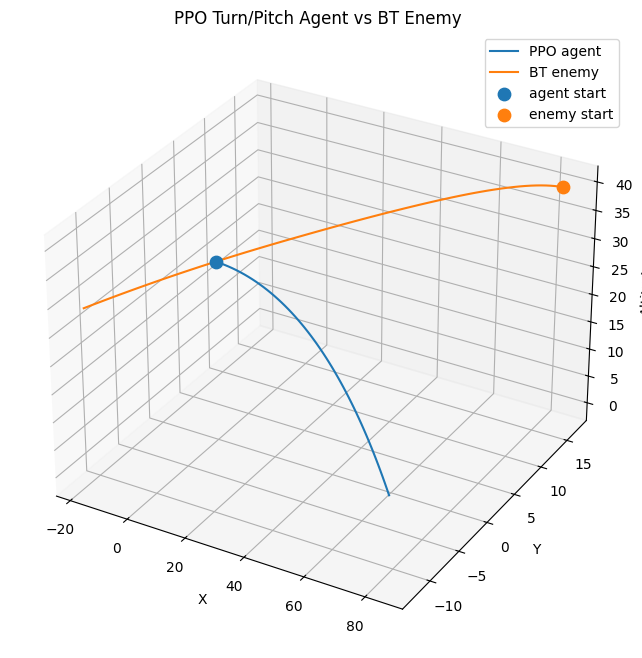

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from src.turn_pitch_bt_env import FighterTurnPitchBTEnv


env = FighterTurnPitchBTEnv()
env.max_steps = 16000000

model = PPO.load("models/ppo_turn_pitch_bt_parallel")

obs, _ = env.reset()

agent_traj = []
enemy_traj = []

agent_hp = []
enemy_hp = []
agent_damage = []
enemy_damage = []
agent_los = []
enemy_los = []
dists = []
agent_energy = []
enemy_energy = []

for _ in range(env.max_steps):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    agent_traj.append(info["agent_pos"])
    enemy_traj.append(info["enemy_pos"])

    agent_hp.append(info["agent_hp"])
    enemy_hp.append(info["enemy_hp"])

    agent_damage.append(info["agent_damage"])
    enemy_damage.append(info["enemy_damage"])

    agent_los.append(info["agent_los_deg"])
    enemy_los.append(info["enemy_los_deg"])

    dists.append(info["dist"])
    agent_energy.append(info["agent_energy"])
    enemy_energy.append(info["enemy_energy"])

    if terminated or truncated:
        break

agent_traj = np.array(agent_traj)
enemy_traj = np.array(enemy_traj)

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(agent_traj[:, 0], agent_traj[:, 1], agent_traj[:, 2], label="PPO agent")
ax.plot(enemy_traj[:, 0], enemy_traj[:, 1], enemy_traj[:, 2], label="BT enemy")

ax.scatter(agent_traj[0, 0], agent_traj[0, 1], agent_traj[0, 2], s=80, label="agent start")
ax.scatter(enemy_traj[0, 0], enemy_traj[0, 1], enemy_traj[0, 2], s=80, label="enemy start")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Altitude")
ax.set_title("PPO Turn/Pitch Agent vs BT Enemy")
ax.legend()
plt.show()

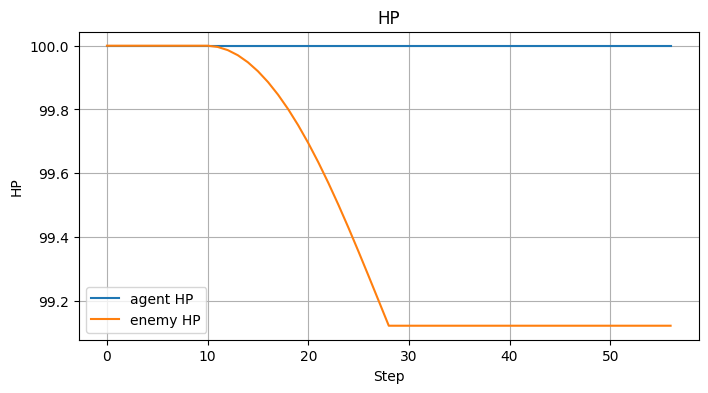

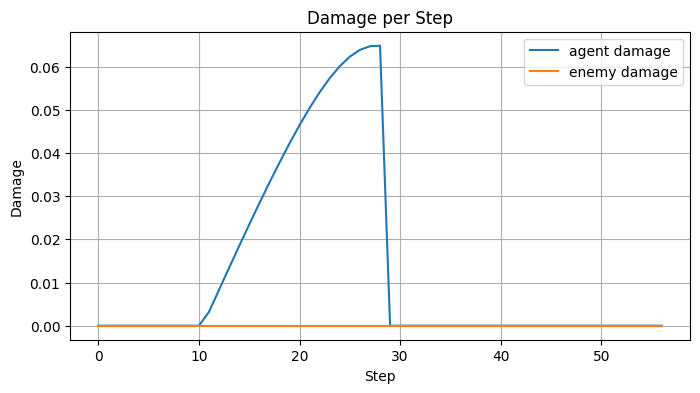

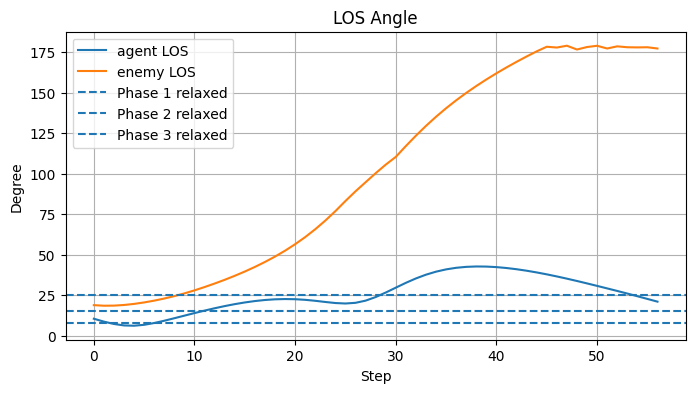

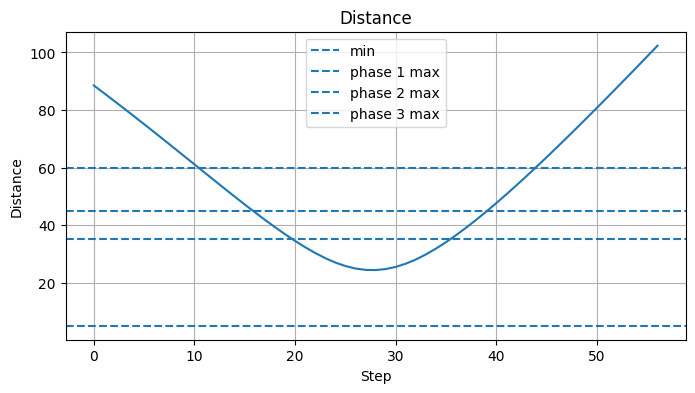

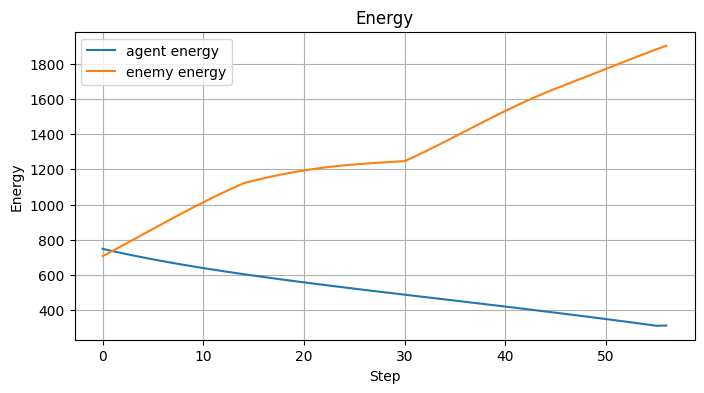

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(agent_hp, label="agent HP")
plt.plot(enemy_hp, label="enemy HP")
plt.title("HP")
plt.xlabel("Step")
plt.ylabel("HP")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(agent_damage, label="agent damage")
plt.plot(enemy_damage, label="enemy damage")
plt.title("Damage per Step")
plt.xlabel("Step")
plt.ylabel("Damage")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(agent_los, label="agent LOS")
plt.plot(enemy_los, label="enemy LOS")
plt.axhline(8.0, linestyle="--", label="Phase 1 relaxed")
plt.axhline(15.0, linestyle="--", label="Phase 2 relaxed")
plt.axhline(25.0, linestyle="--", label="Phase 3 relaxed")
plt.title("LOS Angle")
plt.xlabel("Step")
plt.ylabel("Degree")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(dists)
plt.axhline(5.0, linestyle="--", label="min")
plt.axhline(35.0, linestyle="--", label="phase 1 max")
plt.axhline(45.0, linestyle="--", label="phase 2 max")
plt.axhline(60.0, linestyle="--", label="phase 3 max")
plt.title("Distance")
plt.xlabel("Step")
plt.ylabel("Distance")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(agent_energy, label="agent energy")
plt.plot(enemy_energy, label="enemy energy")
plt.title("Energy")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.grid(True)
plt.legend()
plt.show()